# Solucion LINDA VASQUEZ

## Primer punto: importaciones y logging

In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from sqlalchemy import create_engine

# De acuerdo al feedback de Saúl, agrego logging para rastrear errores
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Entorno configurado correctamente. ¡Listos para empezar!")

2026-05-06 04:42:52,245 - INFO - Entorno configurado correctamente. ¡Listos para empezar!


## Segundo punto: explorar y descargar datos

In [7]:
def get_world_bank_data(countries, indicator, start_year, end_year):
    """
    Consume la API del World Bank para un indicador y lista de países dados.
    """
    # Feedback Saúl, no hardcodear
    base_url = f"https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"
    
    # Feedback Saíl, parametrizar queries
    params = {
        "format": "json",
        "date": f"{start_year}:{end_year}",
        "per_page": 50,
        "page": 1
    }
    
    all_data = []
    
    while True:
        try:
            logging.info(f"Consultando página {params['page']} para el indicador {indicator}...")
            
            # GET
            response = requests.get(base_url, params=params, timeout=10)
            
            # Feedback Saúl, manejo de excepciones por bloqueos o caídas (HTTP Status Code)
            response.raise_for_status() 
            
            # Feedback Saúl, validar encoding
            if response.encoding is None:
                response.encoding = 'utf-8'
                
            payload = response.json()
            
            # Validar si API devolvio datos validos
            if not payload or len(payload) < 2:
                logging.warning("No se encontraron datos o la respuesta está vacía.")
                break
                
            metadata = payload[0] # payload[0] info de paginación
            data = payload[1]     # payload[1] lista de diccionarios con los datos
            
            all_data.extend(data)
            
            # Lógica de paginación
            if params["page"] >= metadata["pages"]:
                break # Salir del ciclo si ya llegó a la última página
            else:
                params["page"] += 1 # Pasar a la siguiente página
                
        except requests.exceptions.RequestException as e:
            logging.error(f"Error de conexión al consultar la API: {e}")
            break
            
    return all_data

paises_abrev = "COL;MEX;CHL;ARG;PER" 
indicador_pib = "NY.GDP.PCAP.CD"

datos_pib_brutos = get_world_bank_data(paises_abrev, indicador_pib, 2010, 2024)
logging.info(f"Se descargaron {len(datos_pib_brutos)} registros en total.")

2026-05-06 04:42:55,056 - INFO - Consultando página 1 para el indicador NY.GDP.PCAP.CD...
2026-05-06 04:42:55,149 - INFO - Consultando página 2 para el indicador NY.GDP.PCAP.CD...
2026-05-06 04:42:55,250 - INFO - Se descargaron 75 registros en total.


## Tercer punto: transformar respuesta a DataFrames

In [8]:
def process_wb_data(raw_data):
    """
    Transforma la respuesta de la API a un DataFrame limpio.
    """
    try:
        if not raw_data:
            logging.warning("No hay datos para procesar.")
            return pd.DataFrame()

        # Extraer datos usando lista de diccionarios
        extracted = []
        for item in raw_data:
            extracted.append({
                "country": item.get("country", {}).get("value"),
                "year": item.get("date"),
                "value": item.get("value")
            })
        
        df = pd.DataFrame(extracted)

        # Eliminar filas donde el valor sea nulo
        df = df.dropna(subset=['value'])

        # Convertir tipos de datis
        df["year"] = pd.to_numeric(df["year"]).astype(int)
        df["value"] = pd.to_numeric(df["value"])

        # Ordenar cronológicamente
        df = df.sort_values(by=["country", "year"])

        logging.info("Transformación a DataFrame completada exitosamente.")
        return df

    except Exception as e:
        logging.error(f"Error inesperado al procesar DataFrame: {e}")
        return pd.DataFrame()

df_pib = process_wb_data(datos_pib_brutos)
print("Vista previa de los datos procesados:")
print(df_pib.head())

2026-05-06 04:42:58,957 - INFO - Transformación a DataFrame completada exitosamente.


Vista previa de los datos procesados:
      country  year         value
14  Argentina  2010  10260.131311
13  Argentina  2011  12704.283182
12  Argentina  2012  12949.717487
11  Argentina  2013  12963.675773
10  Argentina  2014  12233.144412


## Cuarto punto: analisis y visualizaciones

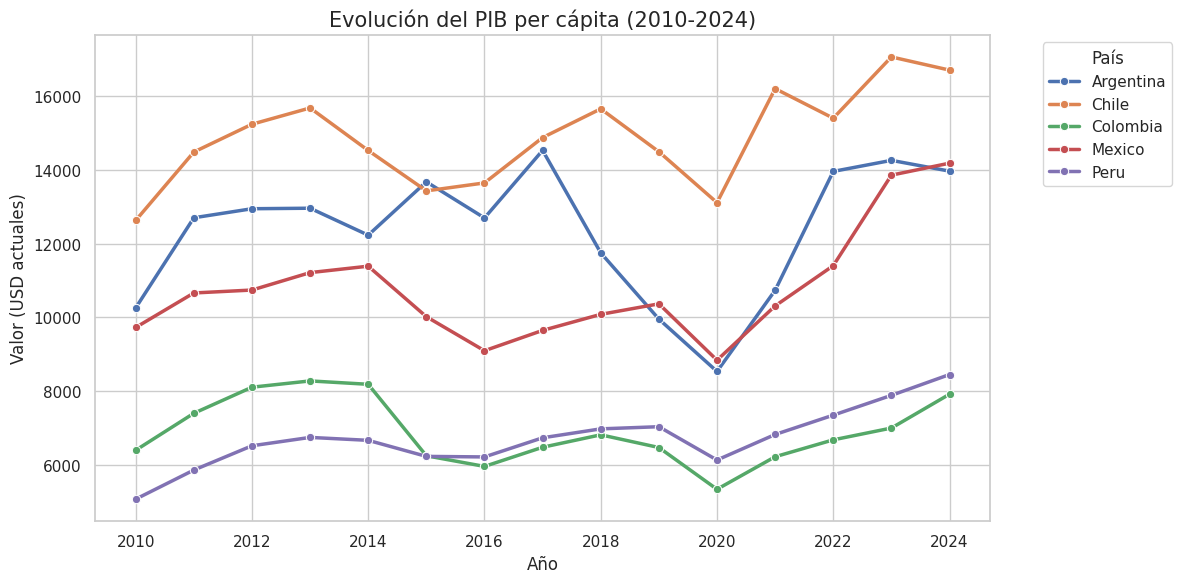

In [9]:
def plot_indicator_trend(df, title_name):
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Gráfico de líneas
    sns.lineplot(data=df, x="year", y="value", hue="country", marker="o", linewidth=2.5)
    
    plt.title(f"Evolución del {title_name} (2010-2024)", fontsize=15)
    plt.xlabel("Año", fontsize=12)
    plt.ylabel("Valor (USD actuales)", fontsize=12)
    plt.legend(title="País", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Mostrar gráfica
plot_indicator_trend(df_pib, "PIB per cápita")

## Quinto punto: cargar resultados a base de datos SQL

In [13]:
import sqlite3

def save_to_db(df, table_name, db_name="world_bank_analysis.db"):
    # Carga el DataFrame en SQLite
    # Tocó incluir un mecanismo de respaldo (Fallback) porque SQLAlchemy fallaba por incompatibilidad de versiones
    try:
        # PLAN A: Usar String URI. En lugar de crear el engine, se le pasa la ruta de texto a Pandas para gestionar SQLAlchemy por debajo sin exponer los objetos.
        conexion_uri = f"sqlite:///{db_name}"
        
        df.to_sql(table_name, con=conexion_uri, if_exists="replace", index=False)
        logging.info(f"PLAN A Exitoso: Datos guardados con SQLAlchemy en la tabla: {table_name}")
        
        # Validar la carga
        df_check = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5", con=conexion_uri)
        print("\nConfirmación de guardado en Base de Datos (Muestra):")
        print(df_check)
        
    except Exception as e:
        logging.warning(f"El Plan A (SQLAlchemy) falló por incompatibilidad del entorno: {e}")
        logging.info("Activando PLAN B: Usando sqlite3 nativo (KISS)...")
        
        # PLAN B: sqlite3 sí usa cursores.
        try:
            # Crear la conexión tradicional
            conn = sqlite3.connect(db_name)
            
            # Guardar los datos
            df.to_sql(table_name, con=conn, if_exists="replace", index=False)
            logging.info(f"PLAN B Exitoso: Datos guardados con sqlite3 en la tabla: {table_name}")
            
            # Validar la carga
            df_check = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5", con=conn)
            print("\nConfirmación de guardado en Base de Datos (Muestra):")
            print(df_check)
            
        except Exception as fallback_error:
            logging.error(f"Error crítico en el Plan B: {fallback_error}")
            
        finally:
            # Se cierra la conexión de sqlite3
            if 'conn' in locals():
                conn.close()

# Ejecución
save_to_db(df_pib, "indicator_gdp_per_capita")

2026-05-06 04:50:54,541 - WARNING - El Plan A (SQLAlchemy) falló por incompatibilidad del entorno: Using URI string without version '2.0.36' or newer of 'sqlalchemy' installed.
2026-05-06 04:50:54,543 - INFO - Activando PLAN B: Usando sqlite3 nativo (KISS)...
2026-05-06 04:50:54,558 - INFO - PLAN B Exitoso: Datos guardados con sqlite3 en la tabla: indicator_gdp_per_capita



Confirmación de guardado en Base de Datos (Muestra):
     country  year         value
0  Argentina  2010  10260.131311
1  Argentina  2011  12704.283182
2  Argentina  2012  12949.717487
3  Argentina  2013  12963.675773
4  Argentina  2014  12233.144412
